# 3D CNN Models — Hand Gesture Recognition

Two models trained directly on raw-pixel video clips from `clip_extraction.ipynb`:
1. **Model A** - a compact 3D CNN (Conv3D stack) trained from scratch
2. **Model B** - pretrained R(2+1)D-18 (Kinetics-400), fine-tuned

Both are evaluated with the shared `src/evaluation/metrics.py` module so results are
directly comparable to the landmark-based branche.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.dataset import GESTURE_NAMES, NUM_CLASSES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.video_dataset import (
    GestureClipDataset, stratified_train_val_split, compute_class_weights,
    IMAGENET_MEAN, IMAGENET_STD, KINETICS_MEAN, KINETICS_STD,
)
from src.models.train_utils import get_device
from src.models.train_utils import train_model, plot_history, predict

CLIP_DIR = "../data/processed"

DEVICE = get_device()  # MPS > CUDA > CPU
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Dataset & DataLoader

Stratified train/val split carved out of the train metadata only (test stays untouched,
official split). 

Class weights are computed from the train split for the weighted loss.

In [2]:
train_df, val_df = stratified_train_val_split(
    f"{CLIP_DIR}/train/_metadata.csv", val_frac=0.15, seed=42
)
print(f"Train: {len(train_df)}   Val: {len(val_df)}")

class_weights = compute_class_weights(train_df, num_classes=NUM_CLASSES)
print("\nClass weights (balanced: N / (num_classes * count)):")
for name, w in zip(GESTURE_NAMES, class_weights):
    print(f"  {name:14s} {w:.3f}")

Train: 2649   Val: 468

Class weights (balanced: N / (num_classes * count)):
  Point-1f       0.322
  Point-2f       0.323
  Click-1f       1.617
  Click-2f       1.617
  Throw-up       1.617
  Throw-down     1.617
  Throw-left     1.617
  Throw-right    1.617
  Open-twice     1.617
  DblClick-1f    1.630
  DblClick-2f    1.617
  Zoom-in        1.617
  Zoom-out       1.617


In [3]:
BATCH_SIZE = 8

# ImageNet stats for the from-scratch model (Model B will use its own
# Kinetics-normalized loaders).
train_ds = GestureClipDataset(train_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=True)
val_ds = GestureClipDataset(val_df, mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)
test_ds = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=IMAGENET_MEAN, std=IMAGENET_STD, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}   Test batches: {len(test_loader)}")

Train batches: 332   Val batches: 59   Test batches: 138


## 2. Sanity check — inspect a batch

In [4]:
clips, labels = next(iter(train_loader))
print(f"Batch clips shape:  {clips.shape}")   # expect (B, 3, 16, 112, 112)
print(f"Batch labels shape: {labels.shape}")
print(f"dtype: {clips.dtype}, value range: [{clips.min():.3f}, {clips.max():.3f}]")
print(f"Labels: {labels.tolist()}")

Batch clips shape:  torch.Size([8, 3, 16, 112, 112])
Batch labels shape: torch.Size([8])
dtype: torch.float32, value range: [-2.118, 2.570]
Labels: [7, 12, 10, 12, 9, 0, 0, 0]


## 3. Visualize a clip — raw vs. augmented

Confirms the augmentation pipeline (flip / crop jitter / temporal jitter / color jitter)
is doing something reasonable.

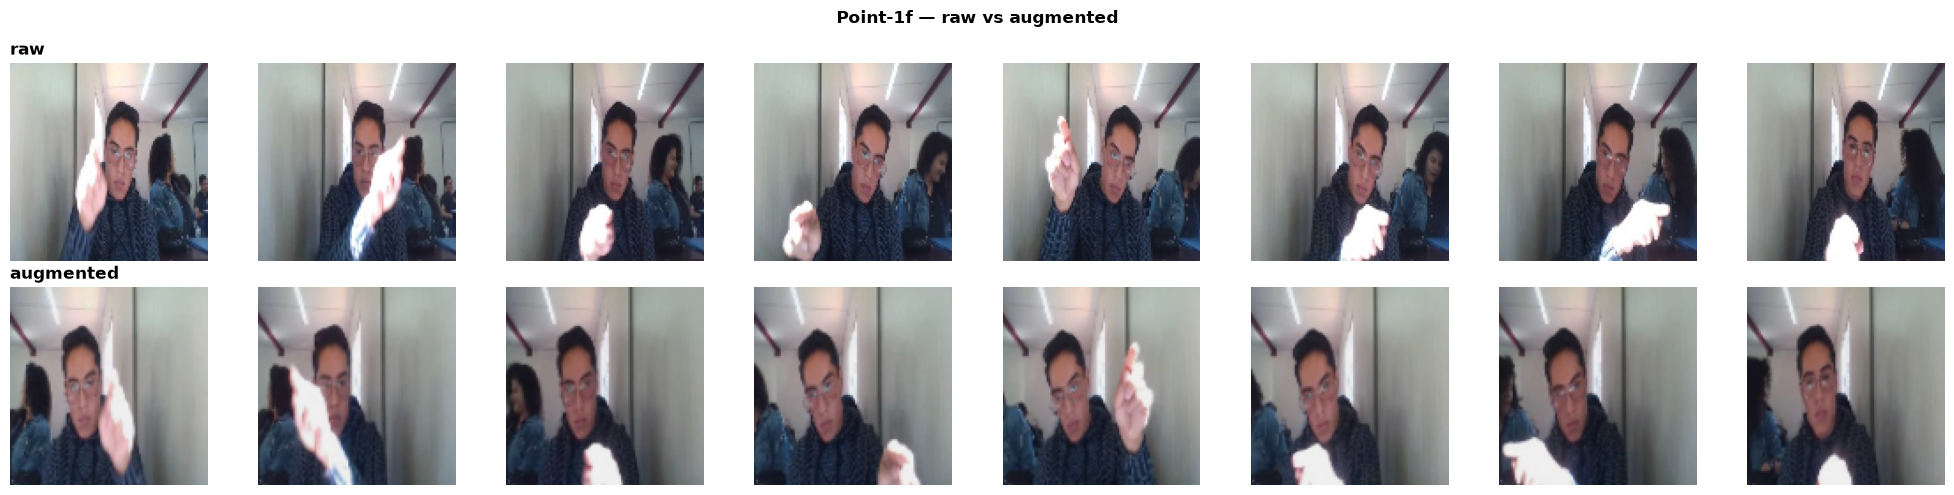

In [5]:
def denormalize(clip_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """(3, T, H, W) normalized tensor -> (T, H, W, 3) uint8 for display."""
    clip = clip_tensor.numpy() * std.reshape(3, 1, 1, 1) + mean.reshape(3, 1, 1, 1)
    clip = np.clip(clip, 0, 1)
    clip = np.transpose(clip, (1, 2, 3, 0))  # (T, H, W, 3)
    return (clip * 255).astype(np.uint8)


idx = 0
raw_clip = np.load(train_df.iloc[idx]['npy_path'])
aug_clip_t, label = train_ds[idx]
aug_clip = denormalize(aug_clip_t)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    axes[0, i].imshow(raw_clip[i * 2]); axes[0, i].axis('off')
    axes[1, i].imshow(aug_clip[i * 2]); axes[1, i].axis('off')
axes[0, 0].set_title("raw", loc='left', fontweight='bold')
axes[1, 0].set_title("augmented", loc='left', fontweight='bold')
plt.suptitle(f"{train_df.iloc[idx]['gesture_name']} — raw vs augmented", fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Model A — 3D CNN from scratch

A compact Conv3D stack, kept small so it trains in reasonable time on MPS:

```
(3,16,112,112) → Conv3D(3→32)  + BN + ReLU + MaxPool3D(2)
               → Conv3D(32→64) + BN + ReLU + MaxPool3D(2)
               → Conv3D(64→128)+ BN + ReLU + MaxPool3D(2)
               → Conv3D(128→256)+BN + ReLU + AdaptiveAvgPool3D(1)
               → FC(256→128) + ReLU + Dropout(0.5) → FC(128→13)
```

In [6]:
from src.models.cnn3d import Simple3DCNN

model_a = Simple3DCNN(num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model_a.parameters())
n_trainable = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Model A parameters: {n_params:,} total, {n_trainable:,} trainable")

# Forward-pass sanity check on a real batch, on-device.
clips, labels = next(iter(train_loader))
with torch.no_grad():
    logits = model_a(clips.to(DEVICE))
print(f"Input shape:  {clips.shape}")
print(f"Output shape: {logits.shape}")   # expect (B, 13)

Model A parameters: 1,199,821 total, 1,199,821 trainable
Input shape:  torch.Size([8, 3, 16, 112, 112])
Output shape: torch.Size([8, 13])


## 5. Training loop — Model A

- Weighted CrossEntropyLoss (class weights from step 1)
- Adam 
- ReduceLROnPlateau
- Early stopping on val loss (patience 10)

In [12]:
from src.models.train_utils import train_model, plot_history, predict

NUM_EPOCHS = 50
PATIENCE = 10

criterion_a = torch.nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode='min', factor=0.5, patience=4)

history_a, model_a = train_model(
    model_a, train_loader, val_loader, criterion_a, optimizer_a, DEVICE,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, scheduler=scheduler_a,
    checkpoint_path="../data/checkpoints/model_a_scratch_best.pth",
    model_name="3DCNN_scratch",
)

[3DCNN_scratch] epoch   1/50 | train_loss 2.3640 acc 0.2488 | val_loss 2.2109 acc 0.3034 | 208.9s
[3DCNN_scratch] epoch   2/50 | train_loss 2.2614 acc 0.2563 | val_loss 2.1193 acc 0.3120 | 297.3s
[3DCNN_scratch] epoch   3/50 | train_loss 2.2205 acc 0.2771 | val_loss 2.1336 acc 0.2927 | 262.2s
[3DCNN_scratch] epoch   4/50 | train_loss 2.1893 acc 0.2839 | val_loss 2.1278 acc 0.2906 | 256.2s
[3DCNN_scratch] epoch   5/50 | train_loss 2.1455 acc 0.2790 | val_loss 2.1135 acc 0.2927 | 263.4s
[3DCNN_scratch] epoch   6/50 | train_loss 2.0951 acc 0.2854 | val_loss 1.9524 acc 0.3526 | 268.4s
[3DCNN_scratch] epoch   7/50 | train_loss 2.0596 acc 0.3069 | val_loss 1.9375 acc 0.3462 | 278.3s
[3DCNN_scratch] epoch   8/50 | train_loss 2.0240 acc 0.2945 | val_loss 1.9708 acc 0.3098 | 277.1s
[3DCNN_scratch] epoch   9/50 | train_loss 1.9822 acc 0.3133 | val_loss 2.1048 acc 0.2821 | 277.9s
[3DCNN_scratch] epoch  10/50 | train_loss 1.9468 acc 0.3228 | val_loss 1.7943 acc 0.3761 | 265.0s
[3DCNN_scratch] epoc

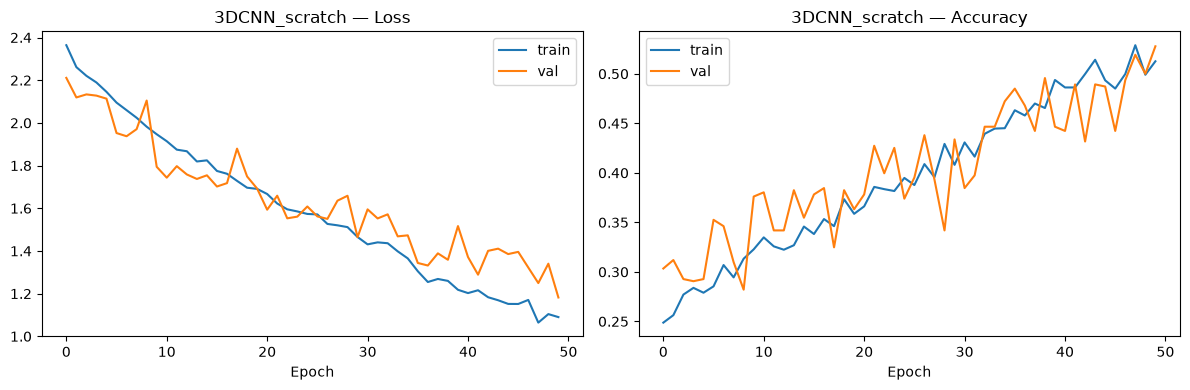

In [13]:
plot_history(history_a, "3DCNN_scratch")

### Resuming without retraining

If the kernel restarts (or you just don't want to wait ~3.7 hours again), skip the
training cell above and run this instead — it loads the already-trained weights
straight from the checkpoint saved during that run

In [7]:
model_a.load_state_dict(torch.load("../data/checkpoints/model_a_scratch_best.pth", map_location=DEVICE))
model_a.eval()
print("Loaded Model A from checkpoint (no training needed).")

Loaded Model A from checkpoint (no training needed).


## 6. Evaluate Model A on the test set


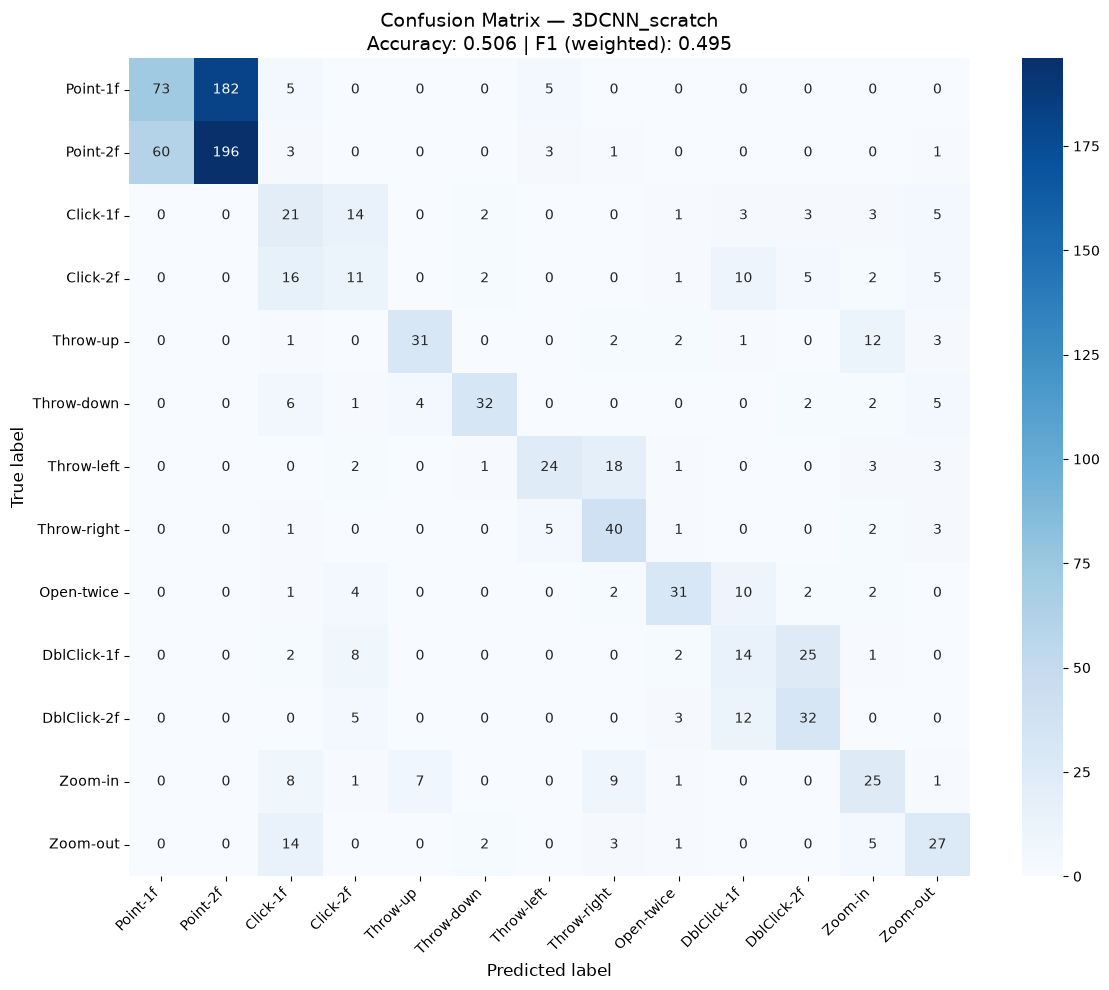

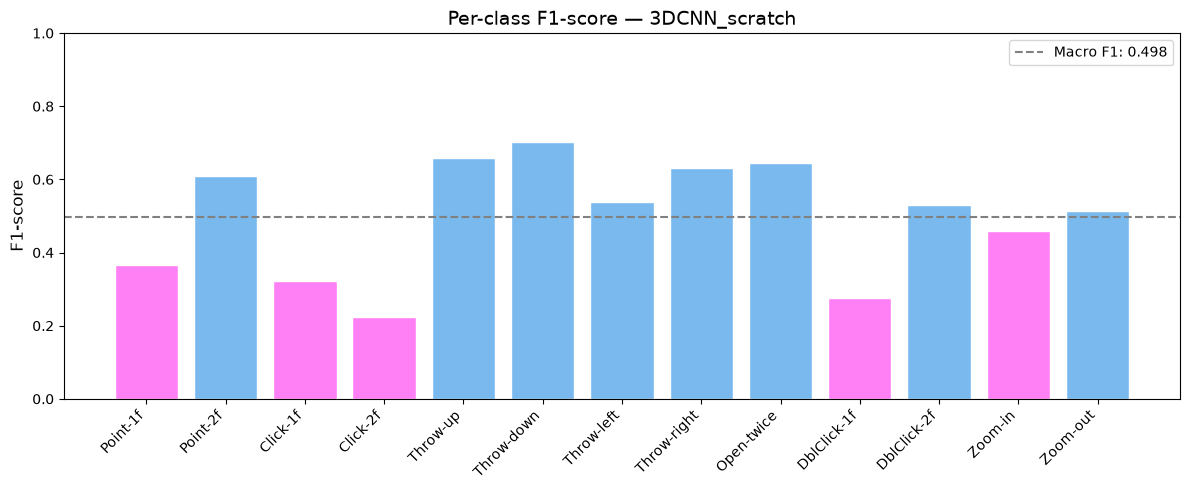


  3DCNN_scratch — Results
  Accuracy:          0.5059
  F1 (weighted):     0.4946
  F1 (macro):        0.4984
  Precision (w):     0.5231
  Recall (w):        0.5059
  Top-3 Accuracy:    0.9128
  Top-5 Accuracy:    0.9637

              precision    recall  f1-score   support

    Point-1f       0.55      0.28      0.37       265
    Point-2f       0.52      0.74      0.61       264
    Click-1f       0.27      0.40      0.32        52
    Click-2f       0.24      0.21      0.22        52
    Throw-up       0.74      0.60      0.66        52
  Throw-down       0.82      0.62      0.70        52
  Throw-left       0.65      0.46      0.54        52
 Throw-right       0.53      0.77      0.63        52
  Open-twice       0.70      0.60      0.65        52
 DblClick-1f       0.28      0.27      0.27        52
 DblClick-2f       0.46      0.62      0.53        52
     Zoom-in       0.44      0.48      0.46        52
    Zoom-out       0.51      0.52      0.51        52

    accuracy      

In [8]:
y_true_a, y_pred_a, y_prob_a = predict(model_a, test_loader, DEVICE)

results_a = full_evaluation(
    y_true_a, y_pred_a, "3DCNN_scratch",
    save_dir="../results/figures", y_prob=y_prob_a
)

In [9]:
from src.models.train_utils import count_parameters

def model_a_predict_fn(x):
    with torch.no_grad():
        return model_a(x)

sample_clip, _ = test_ds[0]
sample_clip = sample_clip.unsqueeze(0).to(DEVICE)  # (1, 3, 16, 112, 112)

timing_a = measure_inference_time(model_a_predict_fn, sample_clip, n_runs=100)
n_params_a, n_trainable_a = count_parameters(model_a)

print(f"Model A — {n_params_a:,} parameters")
print(f"Inference: {timing_a['mean_ms']:.2f} ± {timing_a['std_ms']:.2f} ms  ({timing_a['fps']:.1f} FPS)")

Model A — 1,199,821 parameters
Inference: 9.90 ± 6.43 ms  (101.0 FPS)


### Analysis — Model A: Simple3DCNN (from scratch)

**Overall:** 

Test accuracy **0.506**, weighted F1 **0.495**, macro F1 **0.498**. Top-3 accuracy is **0.913** and Top-5 is **0.964**. 

This is a solid result for a 3D CNN trained from scratch on only ~3,100 training clips. Test accuracy (50.6%) is close to validation accuracy (~52.8%), so the model generalizes well and does not overfit. The very high Top-3 accuracy shows the model almost always ranks the correct class among its top three guesses — it mostly hesitates between visually similar gestures rather than being completely wrong.

**The class imbalance is visible but handled.** 

In the `support` column, `Point-1f` and `Point-2f` have ~265 samples each while all other classes have 52. Because we trained with class-weighted loss, the macro F1 (0.498, which treats every class equally) is almost identical to the weighted F1 — a good sign that the model is not simply exploiting the two dominant classes.

**Confusion matrix**
**Where the model fails:**

- **Point-1f vs Point-2f** is the largest error source: 182 of 265 `Point-1f` samples are misclassified as `Point-2f`. The model essentially cannot tell one finger from two. These are *static* gestures that differ only by the number of extended fingers — a fine spatial detail that is hard to capture from raw 112×112 pixels.

- **Click / DblClick confusion:** `Click-1f`, `Click-2f`, `DblClick-1f`, and `DblClick-2f` are frequently confused with each other (single vs double click, one vs two fingers). These four classes have the lowest F1 scores (0.22–0.32), again because the difference lies in a subtle motion and finger count.

- **Directional throws:** `Throw-left` is confused with `Throw-right` (18 times). The model recognizes the "throw" motion but not always its direction.

**Where the model succeeds:** 

- `Throw-up`, `Throw-down`, `Throw-right`, `Open-twice`, and both `Zoom` gestures all reach F1 above 0.5. These involve large, clear motion over time — precisely what a 3D CNN captures well.

**Summary:** 

3D CNN from scratch model discriminates gestures well by their *motion*, but poorly by fine *static* details such as finger count. This motivates comparing it against (a) the pretrained R(2+1)D-18, whose richer Kinetics-400 features should help on the harder classes, and (b) the landmark-based models, which encode finger geometry explicitly.

In [12]:
import os, json

os.makedirs("../results", exist_ok=True)

summary_a = {
    'model': '3DCNN_scratch',
    'approach': 'raw video clip (3D CNN, from scratch)',
    'accuracy': float(results_a['accuracy']),
    'f1_weighted': float(results_a['f1_weighted']),
    'f1_macro': float(results_a['f1_macro']),
    'inference_ms': float(timing_a['mean_ms']),
    'parameters': int(n_params_a),
    'config': {'architecture': 'Conv3D x4 + FC head', 'batch_size': BATCH_SIZE,
               'num_epochs': 50, 'optimizer': 'Adam', 'lr': 1e-3,
               'dropout': 0.5, 'n_frames': 16, 'resolution': 112},
}

with open("../results/3dcnn_scratch_results.json", "w") as f:
    json.dump(summary_a, f, indent=2)

print(json.dumps(summary_a, indent=2))

{
  "model": "3DCNN_scratch",
  "approach": "raw video clip (3D CNN, from scratch)",
  "accuracy": 0.5059037238873751,
  "f1_weighted": 0.4945585650417449,
  "f1_macro": 0.49841393321443456,
  "inference_ms": 9.902533749118447,
  "parameters": 1199821,
  "config": {
    "architecture": "Conv3D x4 + FC head",
    "batch_size": 8,
    "num_epochs": 50,
    "optimizer": "Adam",
    "lr": 0.001,
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112
  }
}


## 7. Model B — R(2+1)D-18 (trained on Google Colab)

A 31M-parameter pretrained video model is too slow to fine-tune on local MPS, so
this one trains on Google Colab's free GPU instead — see
[`colab_r2plus1d.ipynb`](colab_r2plus1d.ipynb) for the full self-contained script.

The architecture is defined here too (`src/models/r2plus1d.py`). Once training finishes there and the checkpoint is downloaded, it will be
loaded here for evaluation.

In [13]:
from src.models.r2plus1d import build_r2plus1d

model_b = build_r2plus1d(num_classes=NUM_CLASSES).to(DEVICE)

n_params_b = sum(p.numel() for p in model_b.parameters())
print(f"Model B (R(2+1)D-18) parameters: {n_params_b:,}")

# Forward-pass sanity check with Kinetics normalization
test_ds_b = GestureClipDataset(f"{CLIP_DIR}/test/_metadata.csv", mean=KINETICS_MEAN, std=KINETICS_STD, train=False)
clips_b, labels_b = next(iter(DataLoader(test_ds_b, batch_size=4)))
with torch.no_grad():
    logits_b = model_b(clips_b.to(DEVICE))
print(f"Input shape:  {clips_b.shape}")
print(f"Output shape: {logits_b.shape}")   # expect (B, 13)

Model B (R(2+1)D-18) parameters: 31,306,794
Input shape:  torch.Size([4, 3, 16, 112, 112])
Output shape: torch.Size([4, 13])


## 8. Evaluate Model B

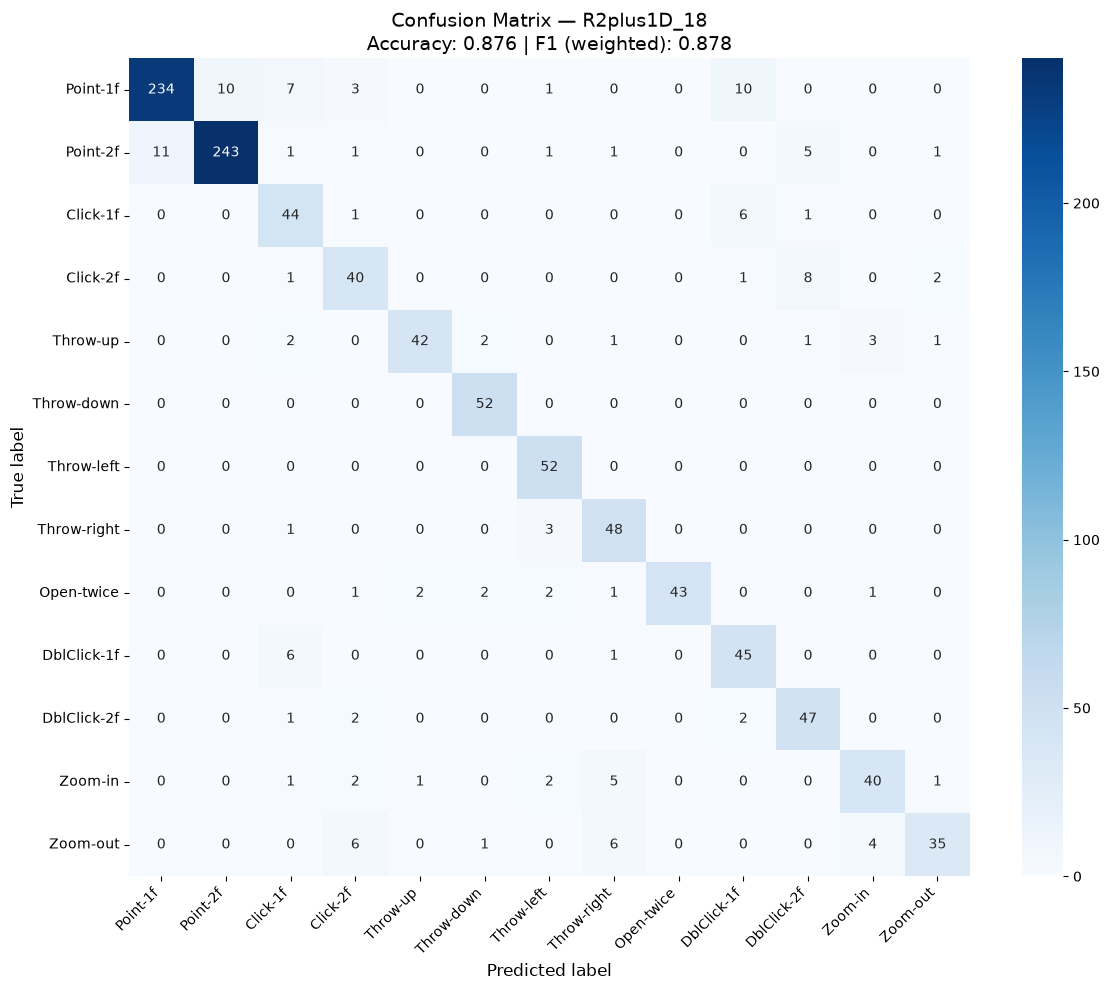

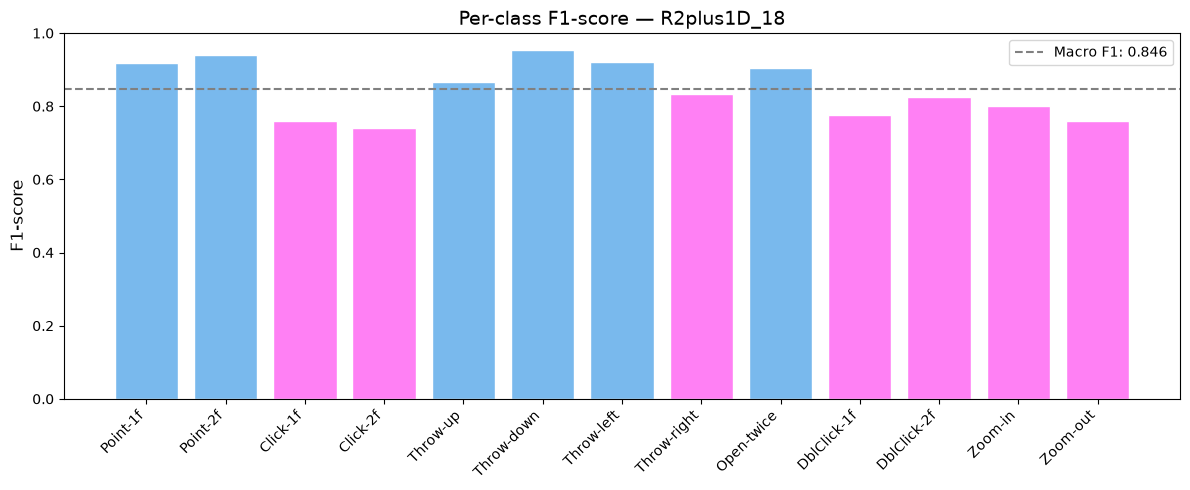


  R2plus1D_18 — Results
  Accuracy:          0.8765
  F1 (weighted):     0.8780
  F1 (macro):        0.8461
  Precision (w):     0.8867
  Recall (w):        0.8765
  Top-3 Accuracy:    0.9691
  Top-5 Accuracy:    0.9837

              precision    recall  f1-score   support

    Point-1f       0.96      0.88      0.92       265
    Point-2f       0.96      0.92      0.94       264
    Click-1f       0.69      0.85      0.76        52
    Click-2f       0.71      0.77      0.74        52
    Throw-up       0.93      0.81      0.87        52
  Throw-down       0.91      1.00      0.95        52
  Throw-left       0.85      1.00      0.92        52
 Throw-right       0.76      0.92      0.83        52
  Open-twice       1.00      0.83      0.91        52
 DblClick-1f       0.70      0.87      0.78        52
 DblClick-2f       0.76      0.90      0.82        52
     Zoom-in       0.83      0.77      0.80        52
    Zoom-out       0.88      0.67      0.76        52

    accuracy        

In [14]:
data = np.load("../results/predictions.npz")
results_b = full_evaluation(
    data['y_true'], data['y_pred'], "R2plus1D_18",
    save_dir="../results/figures", y_prob=data['y_prob']
)

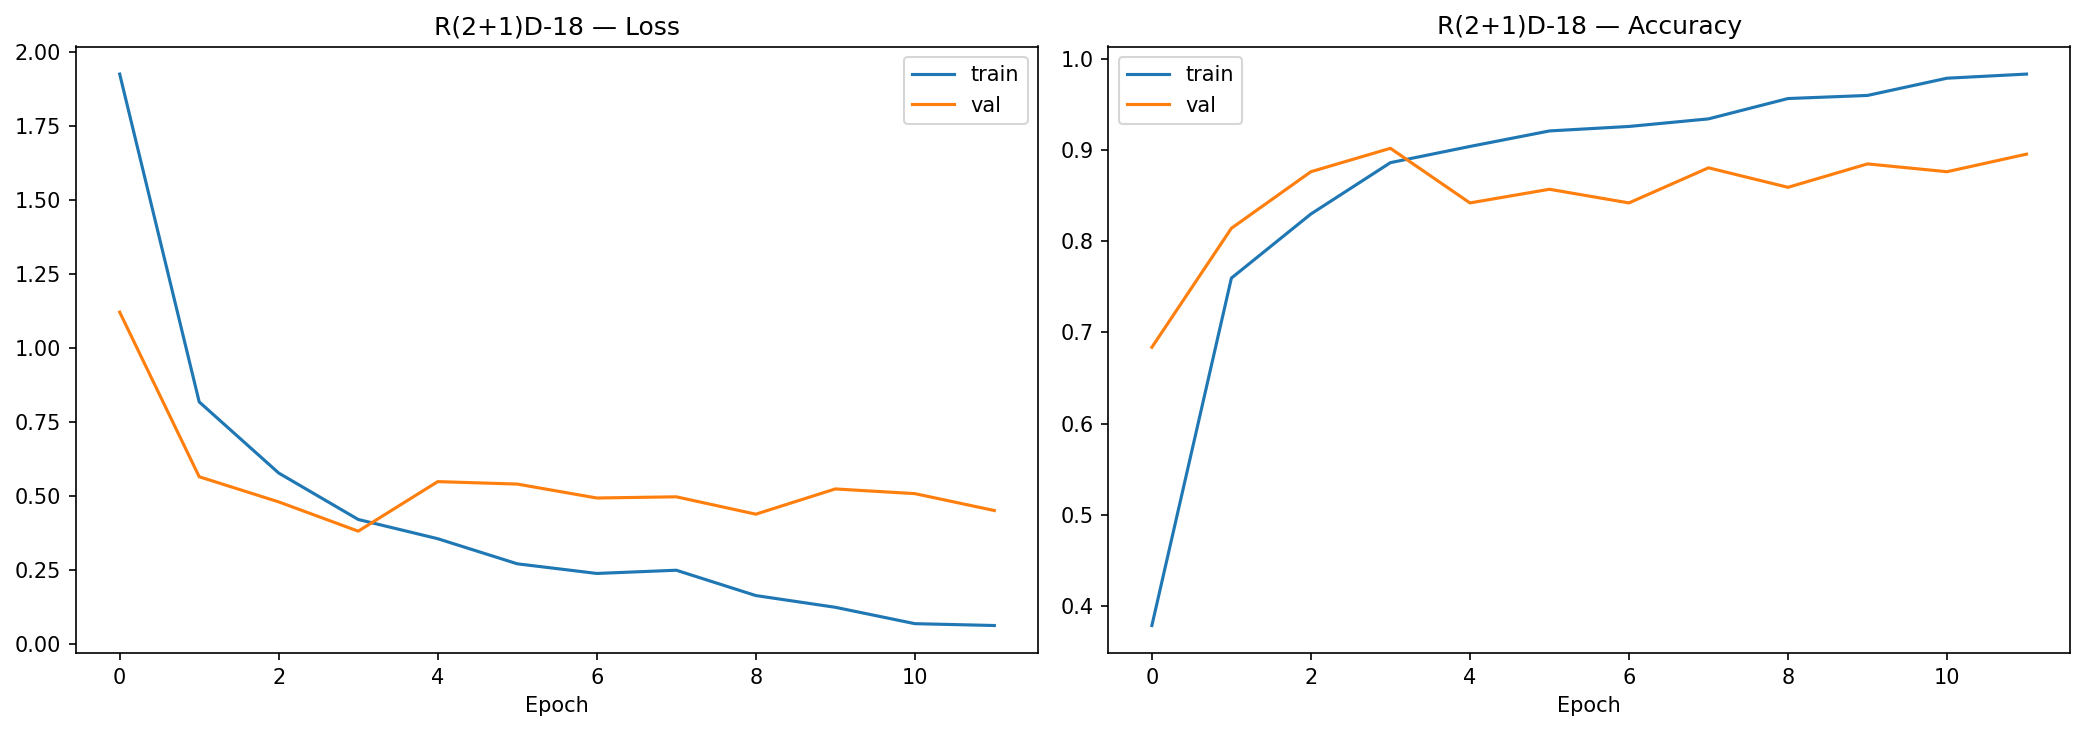

In [20]:
from IPython.display import Image
Image("../results/figures/history_r2plus1d.png")

In [15]:
model_b.load_state_dict(torch.load("../data/checkpoints/best_r2plus1d.pth", map_location=DEVICE))
model_b.eval()
print("Loaded fine-tuned R(2+1)D-18 weights from Colab.")

def model_b_predict_fn(x):
    with torch.no_grad():
        return model_b(x)

sample_clip_b, _ = test_ds_b[0]
sample_clip_b = sample_clip_b.unsqueeze(0).to(DEVICE)  # (1, 3, 16, 112, 112)

timing_b = measure_inference_time(model_b_predict_fn, sample_clip_b, n_runs=100)
n_params_b_total, n_trainable_b = count_parameters(model_b)

print(f"Model B — {n_params_b_total:,} parameters")
print(f"Inference: {timing_b['mean_ms']:.2f} ± {timing_b['std_ms']:.2f} ms  ({timing_b['fps']:.1f} FPS)")

Loaded fine-tuned R(2+1)D-18 weights from Colab.
Model B — 31,306,794 parameters
Inference: 130.46 ± 24.10 ms  (7.7 FPS)


## Analysis — Model B: R(2+1)D-18 (pretrained, transfer learning)

**Overall:** 
Test accuracy **0.876**, a jump of **+37 percentage points** over the from-scratch Simple3DCNN (0.506). 

The model was pretrained on Kinetics-400 and fine-tuned on our clips. Even at epoch 1 the validation accuracy was already ~68%, because the pretrained spatiotemporal features transfer immediately; it then stabilized around 88–90%. 

Training used early stopping, which triggered at epoch 12: training accuracy reached ~98% while validation plateaued near ~89%, and the validation loss curve turned upward around epoch 4–5 while training loss kept falling —  sign of the onset of overfitting that early stopping caught.

**Confusion matrix**
**Transfer learning solves the hard classes.** 

3D CNN from scratch model catastrophically confused `Point-1f` with `Point-2f` (182 of 265 misclassified). R(2+1)D-18 nearly eliminates this error: 

- `Point-1f` now has 234 correct and `Point-2f` 243 correct. 
- The `Click` / `DblClick` group, which had the lowest F1 scores before (0.22–0.32), is now strongly on-diagonal (Click-1f 44, Click-2f 40, DblClick-1f 45, DblClick-2f 47). 
- `Throw-down` and `Throw-left` are perfectly classified (52/52). 

-> The richer pretrained features capture the fine *static* details (finger count) that the from-scratch model could not learn from ~3,100 clips — directly answering the question raised by the Simple3DCNN analysis.

**Remaining errors:** 

- `Zoom-out` is occasionally confused with `Click-2f` and `Throw-right` (6 each), and a few `Point-1f` samples fall into `DblClick-1f` (10). These are minor compared to the earlier confusion.

**Summary:** 

Transfer learning is decisive on this small dataset. R(2+1)D-18 not only raises overall accuracy dramatically but specifically fixes the finger-count and click-type distinctions that pixel-based learning from scratch could not. 

In [16]:
import os, json

os.makedirs("../results", exist_ok=True)

summary_b = {
    'model': 'R2plus1D_18',
    'approach': 'raw video clip (pretrained R(2+1)D-18, fine-tuned)',
    'accuracy': float(results_b['accuracy']),
    'f1_weighted': float(results_b['f1_weighted']),
    'f1_macro': float(results_b['f1_macro']),
    'inference_ms': float(timing_b['mean_ms']),
    'parameters': int(n_params_b_total),
    'config': {'architecture': 'R(2+1)D-18 (Kinetics-400 pretrained)',
               'batch_size': 16, 'num_epochs': 30, 'optimizer': 'Adam',
               'lr': 1e-4, 'weight_decay': 1e-5, 'dropout': 0.5,
               'n_frames': 16, 'resolution': 112, 'trained_on': 'Google Colab (GPU)'},
}

with open("../results/r2plus1d_results.json", "w") as f:
    json.dump(summary_b, f, indent=2)

print(json.dumps(summary_b, indent=2))

{
  "model": "R2plus1D_18",
  "approach": "raw video clip (pretrained R(2+1)D-18, fine-tuned)",
  "accuracy": 0.8764759309718437,
  "f1_weighted": 0.8780082737250027,
  "f1_macro": 0.8460652140255542,
  "inference_ms": 130.4610767494887,
  "parameters": 31306794,
  "config": {
    "architecture": "R(2+1)D-18 (Kinetics-400 pretrained)",
    "batch_size": 16,
    "num_epochs": 30,
    "optimizer": "Adam",
    "lr": 0.0001,
    "weight_decay": 1e-05,
    "dropout": 0.5,
    "n_frames": 16,
    "resolution": 112,
    "trained_on": "Google Colab (GPU)"
  }
}


## 9. Scratch vs. pretrained comparison

How much transfer learning actually buys over the from-scratch 3D CNN — accuracy,
F1, and inference speed side by side, using the shared `compare_models()`.

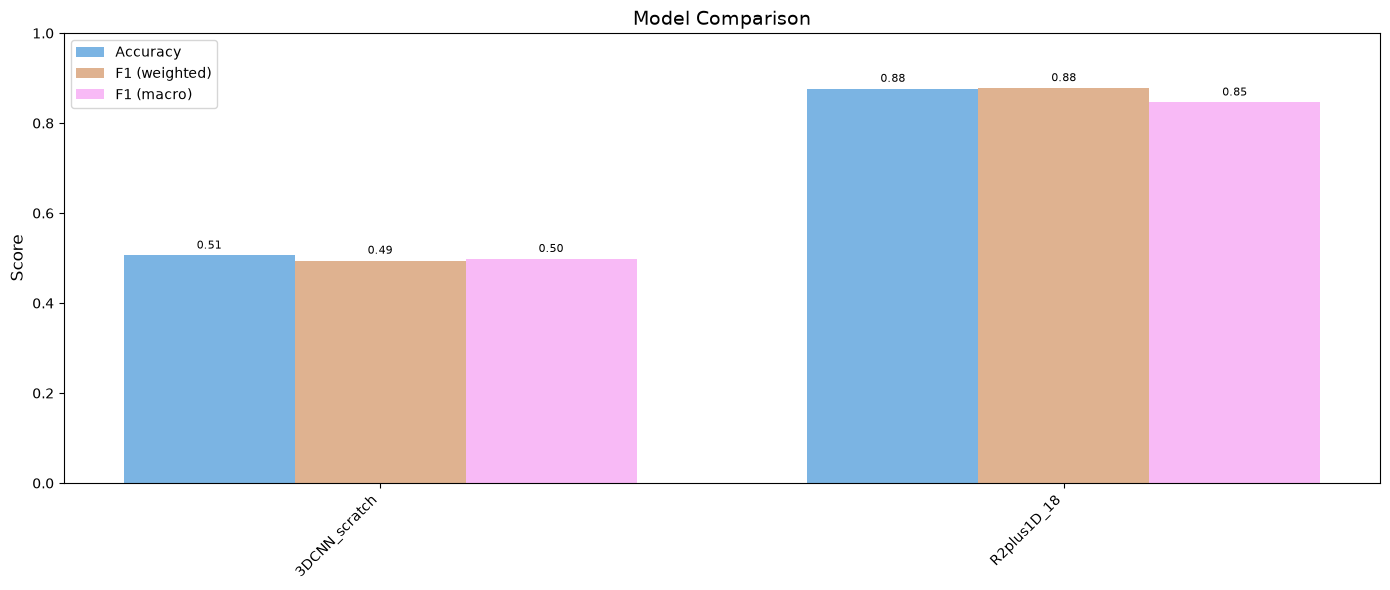


  FINAL MODEL COMPARISON
  Model                       Accuracy     F1 (w)     F1 (m)
  -------------------------------------------------------
  R2plus1D_18                   0.8765     0.8780     0.8461
  3DCNN_scratch                 0.5059     0.4946     0.4984


Model                  Params   Inference FPS
3DCNN_scratch       1,199,821           101.0
R2plus1D_18        31,306,794             7.7


In [17]:
all_results = [results_a, results_b]
compare_models(all_results, save_dir="../results/figures")

print(f"\n{'Model':<16} {'Params':>12} {'Inference FPS':>15}")
print(f"{'3DCNN_scratch':<16} {n_params_a:>12,} {timing_a['fps']:>15.1f}")
print(f"{'R2plus1D_18':<16} {n_params_b_total:>12,} {timing_b['fps']:>15.1f}")